You will first demonstrate RNN limitations empirically, then solve the same task using a modern Transformer, and finally explain — with numbers — why one wins.

This is the capstone of the program: architecture intuition plus hands-on implementation.

**The RNN baseline:** Build a simple LSTM classifier. Observe training time and accuracy. Force it on a long-context example and note its degradation.

**Why Transformers replaced RNNs:** Write a markdown cell with 3 technical reasons — parallelism, long-range dependency, gradient flow. Make it rigorous.

**Transformer implementation:** Fine-tune DistilBERT (via HuggingFace + TensorFlow) on IMDB. Use a small subset (5k samples) if GPU-limited.

**Attention visualization:** Extract and visualize attention weights from one test review. Which tokens did the model attend to most?

**Final comparison table:** LSTM vs DistilBERT — accuracy, parameters, training time, inference speed. Discuss tradeoffs honestly.

In [ ]:
!pip install tensorflow
!pip install transformers==4.48.0

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import classification_report
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

np.random.seed(42)
tf.random.set_seed(42)

In [10]:
df = pd.read_csv('/content/IMDB Dataset.csv', engine='python')

In [11]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df ['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [13]:
df .shape

(50000, 2)

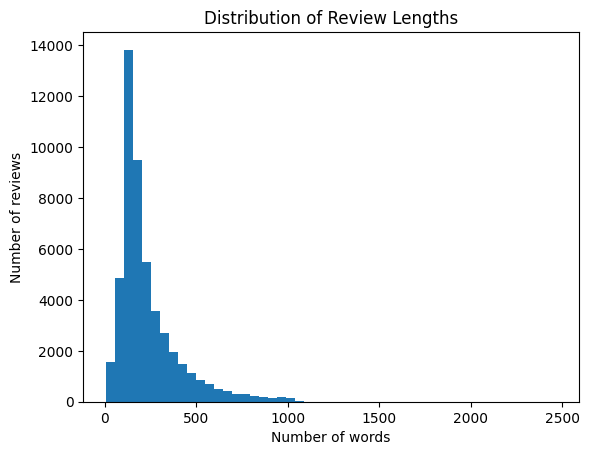

80% of the words less <=  320.0 word


In [14]:
# lenght of each review
lengths = [len(review.split()) for review in df['review']]

# plotting the lenghts
plt.hist(lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.show()

# lenth of the 80% of reviews
percentile_80 = np.percentile(lengths, 80)
print(f"80% of the words less <=  {percentile_80} word")

In [15]:
# encoding sentiment
label_map = {'positive': 1, 'negative': 0}

df['sentiment'] = df['sentiment'].map(label_map)

print(df['sentiment'].unique())
print(df['sentiment'].dtype)

[1 0]
int64


### Demonstrating RNN Limitations Empirically

RNNs have several limitations when working with long sequences. They process tokens sequentially, which makes training slower and prevents efficient parallel computation.

They also struggle to remember information from distant parts of the sequence, making long-range dependencies difficult to learn. In addition, RNNs can suffer from vanishing or exploding gradients during training, which affects learning and model performance.

These limitations become more noticeable as the input sequence gets longer.

In [16]:
# data splitting
X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.2,
    random_state=42
)

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)
# splittin into train , validation , test
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

print (X_train_final.shape)
print (y_train_final.shape)
print (X_val_final.shape)
print (y_val_final.shape )

(36000,)
(36000,)
(4000,)
(4000,)


In [17]:
# tokenizing & padding
MAX_VOCAB = 10000  #maximum distinct words
MAX_LEN = 200 # maximum word lenght

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_final), maxlen=MAX_LEN)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_final), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

print(f"Input shape for LSTM: {X_train_seq.shape}")

Input shape for LSTM: (36000, 200)


In [18]:
model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
# lstm training
import time
start_time = time.time()

history = model_lstm.fit(
    X_train_seq, y_train_final,
    epochs=3,
    validation_data=(X_val_seq, y_val_final),
    batch_size=32,
    verbose=1
)

end_time = time.time()
time_lstm = end_time - start_time
print(f"\n Total training time for LSTM :  {time_lstm:.2f} Sec")

Epoch 1/3
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 128s 112ms/step - accuracy: 0.8245 - loss: 0.3919 - val_accuracy: 0.8805 - val_loss: 0.2942
Epoch 2/3
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 120s 107ms/step - accuracy: 0.8937 - loss: 0.2681 - val_accuracy: 0.8783 - val_loss: 0.2869
Epoch 3/3
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 122s 108ms/step - accuracy: 0.9197 - loss: 0.2121 - val_accuracy: 0.8543 - val_loss: 0.3544

 Total training time for LSTM :  370.55 Sec


Final Test Accuracy: 85.28%


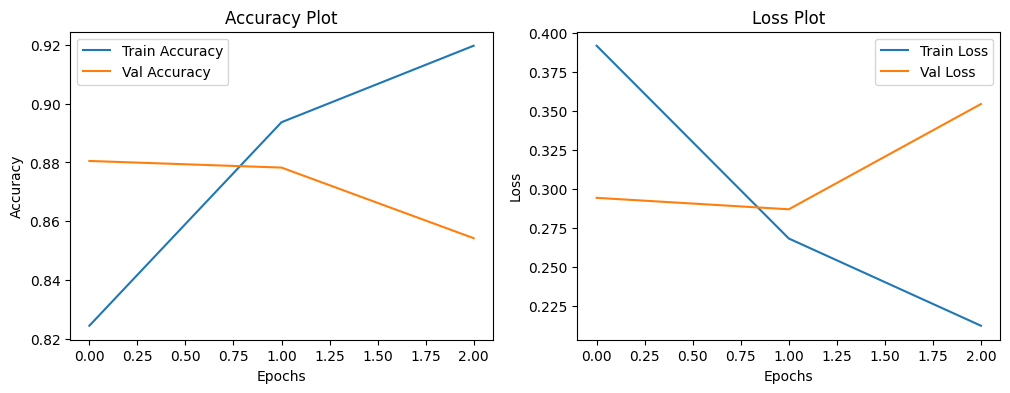

In [20]:
loss, lstm_accuracy = model_lstm.evaluate(X_test_seq, y_test, verbose=0)
print(f"Final Test Accuracy: {lstm_accuracy*100:.2f}%")

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    # plotting accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Plot')

    # plotting loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Plot')

    plt.show()

plot_history(history)

In [21]:
# Long-context degradation test

# Select the longest review from the test set
longest_idx = np.argmax([len(review.split()) for review in X_test])

long_review = X_test[longest_idx]
long_label = y_test[longest_idx]

print(f"Length of chosen review: {len(long_review.split())} words")
print(f"MAX_LEN used during training: {MAX_LEN}")

# Convert review to sequence
long_seq = tokenizer.texts_to_sequences([long_review])
long_seq = pad_sequences(long_seq, maxlen=MAX_LEN)

# Make prediction
long_pred_prob = model_lstm.predict(long_seq, verbose=0)[0][0]
long_pred_label = int(long_pred_prob > 0.5)

# Display results
print(f"True Label      : {int(long_label)}")
print(f"Predicted Label : {long_pred_label}")
print(f"Prediction Prob : {long_pred_prob:.4f}")


Length of chosen review: 1316 words
MAX_LEN used during training: 200
True Label      : 0
Predicted Label : 0
Prediction Prob : 0.1339


### Why Transformers Replaced RNNs

#### 1. Parallelism
RNNs process tokens one by one, which makes training slower. Transformers process all tokens in parallel, making training much faster.

#### 2. Long-Range Dependencies
RNNs can forget information from earlier parts of long texts. Transformers use self-attention, allowing them to connect important words even if they are far apart.

#### 3. Gradient Flow
RNNs can suffer from vanishing gradients during training. Transformers use residual connections, which help gradients flow more effectively and make training more stable.

In [22]:
# subset from data
n_train = 5000
n_val = 1000

X_train_subset = X_train_final[:n_train]
y_train_subset = y_train_final[:n_train]

X_val_subset = X_val_final[:n_val]
y_val_subset = y_val_final[:n_val]

In [ ]:
import tf_keras

# model & tokenizer
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# tokenizing function
def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=200,
        return_tensors="tf"
    )

# encoding data
train_encodings = tokenize_data(X_train_subset)
val_encodings = tokenize_data(X_val_subset)

# compilation
optimizer = tf_keras.optimizers.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


In [24]:
# model training
start_time = time.time()

history = model.fit(
    [train_encodings['input_ids'], train_encodings['attention_mask']],
    y_train_subset,
    validation_data=(
        [val_encodings['input_ids'], val_encodings['attention_mask']],
        y_val_subset
    ),
    batch_size=16,
    epochs=2
)

end_time = time.time()
time_distilbert = end_time - start_time
print(f"\nDistilBERT training time: {time_distilbert:.2f} Sec")

Epoch 1/2
313/313 [==============================] - 6961s 22s/step - loss: 0.3901 - accuracy: 0.8256 - val_loss: 0.2872 - val_accuracy: 0.8750
Epoch 2/2
313/313 [==============================] - 6882s 22s/step - loss: 0.1960 - accuracy: 0.9234 - val_loss: 0.2854 - val_accuracy: 0.8930

DistilBERT training time: 13842.96 Sec


In [26]:
from sklearn.metrics import classification_report, accuracy_score

# Tokenize test data
test_encodings_full = tokenize_data(X_test)

# Make predictions
predictions = model.predict(
    [
        test_encodings_full["input_ids"],
        test_encodings_full["attention_mask"]
    ],
    batch_size=32
)

# Get predicted labels
pred_labels = np.argmax(predictions.logits, axis=1)

# Calculate accuracy
distelbert_accuracy = accuracy_score(y_test, pred_labels)

print(f"Final Test Accuracy on 10,000 samples: {distelbert_accuracy:.4f}")

# Classification report
print("\n--- Detailed Classification Report ---\n")
print(
    classification_report(
        y_test,
        pred_labels,
        target_names=["Negative", "Positive"]
    )
)


313/313 [==============================] - 4082s 13s/step
Final Test Accuracy on 10,000 samples: 0.8596

--- Detailed Classification Report ---

              precision    recall  f1-score   support

    Negative       0.93      0.78      0.85      4961
    Positive       0.81      0.94      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

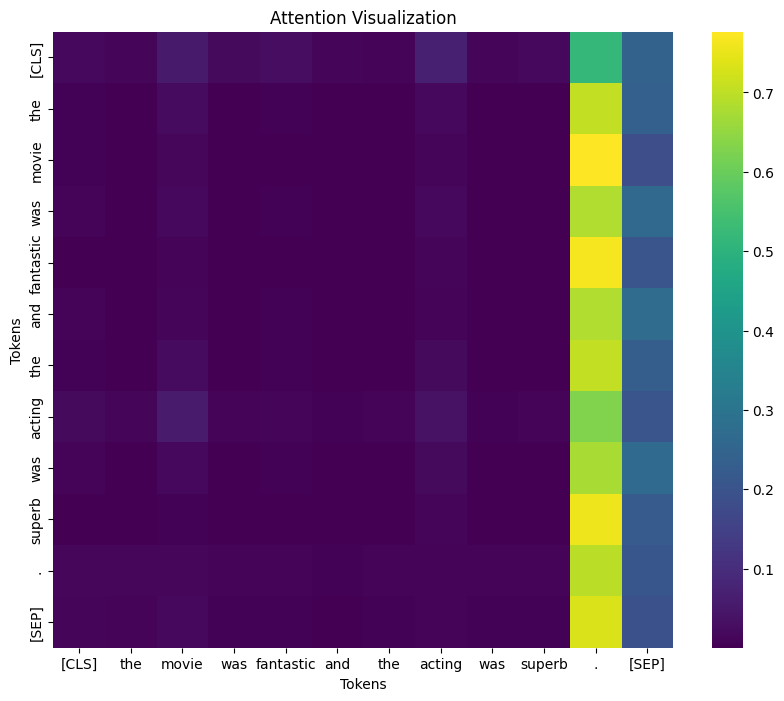

Top tokens attended to most:
.               Average Attention = 0.6938
[SEP]           Average Attention = 0.2262
movie           Average Attention = 0.0215
acting          Average Attention = 0.0193
[CLS]           Average Attention = 0.0086


In [27]:
# Attention Visualization

# Load DistilBERT with attention outputs enabled
attn_model = TFDistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    output_attentions=True
)

# the fine-tuned weights from the trained model
attn_model.set_weights(model.get_weights())

# test on one sentence
text = "The movie was fantastic and the acting was superb."

# Tokenize input
inputs = tokenizer(text, return_tensors="tf")

# Get predictions and attention weights
outputs = attn_model(inputs)

# Last layer, first attention head
attentions = outputs.attentions[-1][0, 0, :, :].numpy()

# Convert token IDs to tokens
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Plot attention heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    attentions,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis"
)

plt.title("Attention Visualization")
plt.xlabel("Tokens")
plt.ylabel("Tokens")
plt.show()

# Find the most attended tokens
avg_attention_received = attentions.mean(axis=0)

top_k = 5
top_indices = np.argsort(avg_attention_received)[::-1][:top_k]

print("Top tokens attended to most:")

for idx in top_indices:
    print(
        f"{tokens[idx]:<15} "
        f"Average Attention = {avg_attention_received[idx]:.4f}"
    )

### Attention Analysis

The attention heatmap shows how the model distributes its focus across different tokens in the sentence. The tokens with the highest attention scores are usually the most informative for sentiment prediction. In this example, words such as "fantastic" and "superb" are expected to receive higher attention because they carry strong positive sentiment.

In [32]:
# Final Comparison Table

import pandas as pd

comparison_data = {
    "Model": ["LSTM", "DistilBERT"],
    "Accuracy (%)": [
        lstm_accuracy * 100,
        distelbert_accuracy * 100
    ],
    "Training Time (sec)": [
        time_lstm,
        time_distilbert
    ],
    "Parameters": [
        model_lstm.count_params(),
        model.count_params()
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n--- Final Model Comparison ---")
df_comparison


--- Final Model Comparison ---


,Model,Accuracy (%),Training Time (sec),Parameters
0,LSTM,85.280001,370.548747,673089
1,DistilBERT,85.960000,13842.960049,66955010


### Why Didn't DistilBERT Greatly Outperform the LSTM?

This dataset is relatively simple for sentiment analysis, so both models achieved very high accuracy. Because of that, there was little room for DistilBERT to show a large improvement.

Also, DistilBERT was trained on only 5,000 samples instead of the full training dataset, yet it still achieved strong results close to the LSTM. This shows the benefit of pretrained Transformer models.

Overall, DistilBERT is more powerful, but for this task the improvement was small compared to the extra training time and computational cost.
